# LAB 7: ABC del aprendizaje de máquina 
## Víctor Palacios (1017271469)

# Problema

El dataset de viviendas de California corresponde a un conjunto de datos basado en el censo de 1990, que contiene información sobre los precios medios de las viviendas junto con diversas características demográficas y estructurales de los distritos en el estado de California.

A continuación, se describen las variables incluidas en el dataset:

- **longitude**: longitud del centroide del distrito (en grados). Indica la posición geográfica en el eje este-oeste.

- **latitude**: latitud del centroide del distrito (en grados). Indica la posición geográfica en el eje norte-sur.

- **housing_median_age**: edad media de las viviendas en el distrito (en años). Proporciona una aproximación al estado y antigüedad de las construcciones.

- **total_rooms**: número total de habitaciones en el distrito, sin distinción de tipo. Refleja la capacidad habitacional agregada.

- **total_bedrooms**: número total de dormitorios en el distrito. Representa los espacios destinados al descanso dentro de las viviendas.

- **population**: número total de habitantes del distrito. Permite inferir la densidad poblacional y la presión sobre la vivienda.

- **households**: número de hogares en el distrito. Un hogar corresponde a un grupo de personas que habitan una misma vivienda; esta variable describe la estructura residencial.

- **median_income**: ingreso medio por hogar (expresado en miles de dólares, $10^3$ USD). Indica el nivel socioeconómico de los residentes.

- **median_house_value**: valor medio de las viviendas (expresado en cientos de miles de dólares, $10^5$ USD). Esta es la **variable objetivo** del problema, ya que representa el precio promedio de las propiedades en cada distrito.

## TAREA

1. Leer el data frame en formato csv en la dirección 
https://raw.githubusercontent.com/hernansalinas/Curso_aprendizaje_estadistico/main/datasets/Sesion_07_housing.csv

In [1]:
import pandas as pd

# 1. Carga del conjunto de datos
url = "https://raw.githubusercontent.com/hernansalinas/Curso_aprendizaje_estadistico/main/datasets/Sesion_07_housing.csv"
df = pd.read_csv(url)

# 2. Inspección rápida de la estructura
print("Dimensiones del dataset:", df.shape)
print("\nPrimeras 5 filas:")
print(df.head())

# 3. Tipos de datos e información general
print("\nInformación de las columnas y tipos de datos:")
print(df.info())

Dimensiones del dataset: (20640, 10)

Primeras 5 filas:
   longitude  latitude  housing_median_age  total_rooms  total_bedrooms  \
0    -122.23     37.88                41.0        880.0           129.0   
1    -122.22     37.86                21.0       7099.0          1106.0   
2    -122.24     37.85                52.0       1467.0           190.0   
3    -122.25     37.85                52.0       1274.0           235.0   
4    -122.25     37.85                52.0       1627.0           280.0   

   population  households  median_income  median_house_value ocean_proximity  
0       322.0       126.0         8.3252            452600.0        NEAR BAY  
1      2401.0      1138.0         8.3014            358500.0        NEAR BAY  
2       496.0       177.0         7.2574            352100.0        NEAR BAY  
3       558.0       219.0         5.6431            341300.0        NEAR BAY  
4       565.0       259.0         3.8462            342200.0        NEAR BAY  

Información de las

2. Entender el estado de los datos, para ello puedo emplear los comandos básicos del pandas

df.info()

df.describe()

df.isnull().sum()

df.isna().sum()

In [2]:
# 1. Información general de tipos y conteos
print("--- Información General ---")
print(df.info())

# 2. Resumen estadístico (Detección de outliers y escalas)
print("\n--- Resumen Estadístico ---")
print(df.describe())

# 3. Detección de valores faltantes (Ambas funciones son equivalentes)
print("\n--- Valores Faltantes ---")
print(df.isnull().sum())

--- Información General ---
<class 'pandas.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  float64
 3   total_rooms         20640 non-null  float64
 4   total_bedrooms      20433 non-null  float64
 5   population          20640 non-null  float64
 6   households          20640 non-null  float64
 7   median_income       20640 non-null  float64
 8   median_house_value  20640 non-null  float64
 9   ocean_proximity     20640 non-null  str    
dtypes: float64(9), str(1)
memory usage: 1.6 MB
None

--- Resumen Estadístico ---
          longitude      latitude  housing_median_age   total_rooms  \
count  20640.000000  20640.000000        20640.000000  20640.000000   
mean    -119.569704     35.631861           28.639486   2635.7

In [3]:
print(df[['median_income', 'median_house_value', 'total_rooms' ]].describe())

       median_income  median_house_value   total_rooms
count   20640.000000        20640.000000  20640.000000
mean        3.870671       206855.816909   2635.763081
std         1.899822       115395.615874   2181.615252
min         0.499900        14999.000000      2.000000
25%         2.563400       119600.000000   1447.750000
50%         3.534800       179700.000000   2127.000000
75%         4.743250       264725.000000   3148.000000
max        15.000100       500001.000000  39320.000000


Estos dos últimos son equivalentes: 

3. ¿Cuántas variables tiene el dataset y de qué tipo son?

In [4]:
# Conteo de variables y tipos
print(f"El dataset tiene {df.shape[1]} variables (columnas).")
print("\nTipos de datos por columna:")
print(df.dtypes)

# Conteo de tipos de datos
print("\nResumen de tipos de datos:")
print(df.dtypes.value_counts())

El dataset tiene 10 variables (columnas).

Tipos de datos por columna:
longitude             float64
latitude              float64
housing_median_age    float64
total_rooms           float64
total_bedrooms        float64
population            float64
households            float64
median_income         float64
median_house_value    float64
ocean_proximity           str
dtype: object

Resumen de tipos de datos:
float64    9
str        1
Name: count, dtype: int64


4. ¿Existen valores faltantes? ¿En qué variables estan? ¿cuántos son?

In [5]:
# Calcular la suma de valores nulos por cada columna
valores_faltantes = df.isnull().sum()

# Filtrar solo aquellas columnas que tienen más de 0 valores faltantes
solo_faltantes = valores_faltantes[valores_faltantes > 0]

print("Variables con valores faltantes y su cantidad:")
print(solo_faltantes)

# Calcular el porcentaje para dimensionar el problema
porcentaje_faltantes = (solo_faltantes / len(df)) * 100
print("\nPorcentaje de valores faltantes respecto al total:")
print(porcentaje_faltantes)

Variables con valores faltantes y su cantidad:
total_bedrooms    207
dtype: int64

Porcentaje de valores faltantes respecto al total:
total_bedrooms    1.002907
dtype: float64


Basado en el análisis del dataset de California Housing:

**¿Existen valores faltantes?**
Sí, existen valores faltantes en el conjunto de datos.

**¿En qué variables están?**
Únicamente en la variable total_bedrooms (total de dormitorios).

**¿Cuántos son?**
Hay 207 registros con valores nulos (NaN).

5. Determinar los elementos únicos dentro de la columna **ocean_proximity**

In [6]:
# Obtener los valores únicos de la columna ocean_proximity
valores_unicos = df['ocean_proximity'].unique()

# Contar cuántas veces aparece cada valor (frecuencia)
conteo_categorias = df['ocean_proximity'].value_counts()

print("Elementos únicos en 'ocean_proximity':")
print(valores_unicos)

print("\nFrecuencia de cada categoría:")
print(conteo_categorias)

Elementos únicos en 'ocean_proximity':
<StringArray>
['NEAR BAY', '<1H OCEAN', 'INLAND', 'NEAR OCEAN', 'ISLAND']
Length: 5, dtype: str

Frecuencia de cada categoría:
ocean_proximity
<1H OCEAN     9136
INLAND        6551
NEAR OCEAN    2658
NEAR BAY      2290
ISLAND           5
Name: count, dtype: int64


6. Para las columnas

cols = ["housing_median_age",   "total_rooms",  "total_bedrooms",   "population",   "households",   "median_income",    "median_house_value"]

Determinar el promedio de cada una de las columnas asociado a cada elementos unico de ocean_proximity, intenta con la operación groupby.

In [7]:
# Definir las columnas de interés
cols = ["housing_median_age", "total_rooms", "total_bedrooms", 
        "population", "households", "median_income", "median_house_value"]

# Agrupar por 'ocean_proximity' y calcular el promedio para las columnas seleccionadas
resumen_por_proximidad = df.groupby('ocean_proximity')[cols].mean()

# Mostrar el resultado
print("Promedio de variables según proximidad al océano:")
print(resumen_por_proximidad)

Promedio de variables según proximidad al océano:
                 housing_median_age  total_rooms  total_bedrooms   population  \
ocean_proximity                                                                 
<1H OCEAN                 29.279225  2628.343586      546.539185  1520.290499   
INLAND                    24.271867  2717.742787      533.881619  1391.046252   
ISLAND                    42.400000  1574.600000      420.400000   668.000000   
NEAR BAY                  37.730131  2493.589520      514.182819  1230.317467   
NEAR OCEAN                29.347254  2583.700903      538.615677  1354.008653   

                 households  median_income  median_house_value  
ocean_proximity                                                 
<1H OCEAN        517.744965       4.230682       240084.285464  
INLAND           477.447565       3.208996       124805.392001  
ISLAND           276.600000       2.744420       380440.000000  
NEAR BAY         488.616157       4.172885       259212.3

7. Construye un histograma para cada columna, puede emplear la libreria de seaborn.

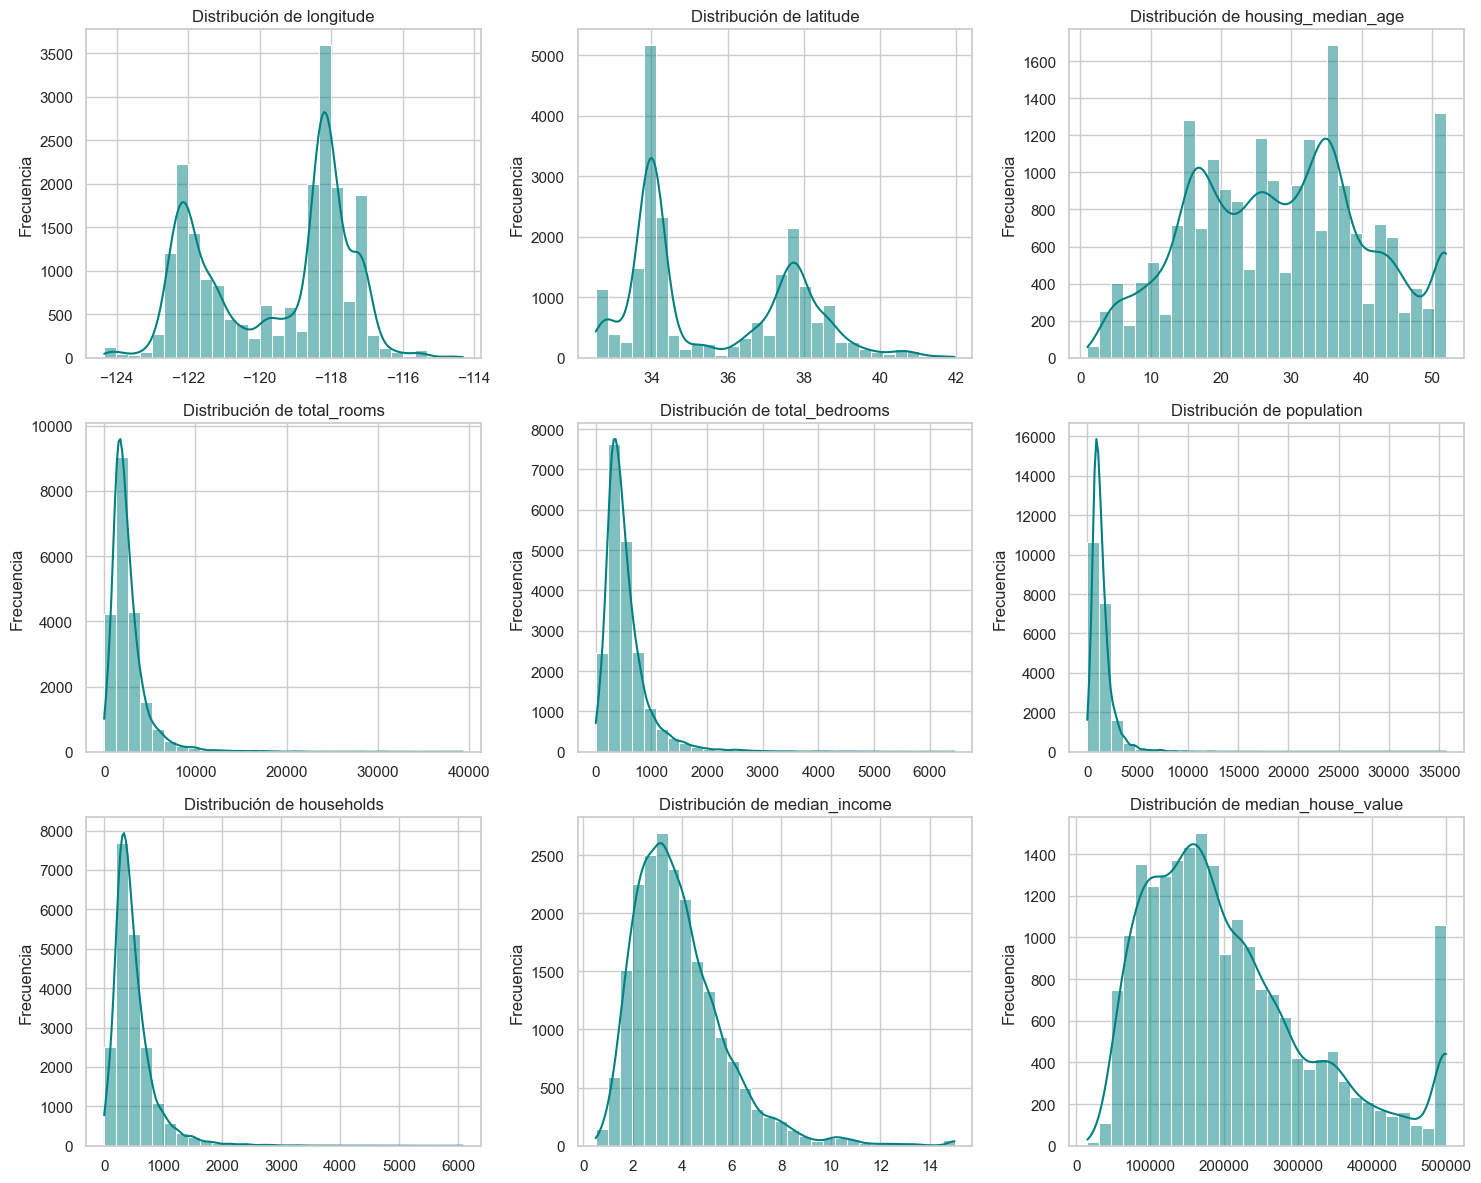

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns

# Configuración de estilo
sns.set_theme(style="whitegrid")

# Seleccionar solo las columnas numéricas para los histogramas
cols_numericas = df.select_dtypes(include=['float64', 'int64']).columns

# Crear una figura con subplots
fig, axes = plt.subplots(nrows=3, ncols=3, figsize=(15, 12))
axes = axes.flatten()

for i, col in enumerate(cols_numericas):
    sns.histplot(df[col], bins=30, kde=True, ax=axes[i], color='teal')
    axes[i].set_title(f'Distribución de {col}', fontsize=12)
    axes[i].set_xlabel('')
    axes[i].set_ylabel('Frecuencia')

# Ajustar el diseño para que no se traslapen
plt.tight_layout()
plt.show()

**Análisis de los Histogramas**

Al observar estos gráficos, podemos realizar las siguientes observaciones técnicas fundamentales para el éxito del modelo:

1.  **Asimetría (Skewness):** 
    *   Variables como `total_rooms`, `total_bedrooms`, `population` y `households` están fuertemente **sesgadas a la derecha** (tienen una cola larga hacia valores altos). 
    *   *Implicación:* Los modelos lineales suelen funcionar mejor con distribuciones en forma de campana (normales). En el **Punto 5 (Feature Engineering)**, podrías considerar aplicar una transformación logarítmica.

2.  **Valores Truncados (Capping):**
    *   **`median_house_value`**: Notarás un pico muy alto al final del gráfico (en 500,001). Esto confirma que los valores superiores a ese monto fueron agrupados ahí.
    *   **`housing_median_age`**: También muestra un pico al final (alrededor de 52 años).
    *   *Riesgo:* El modelo podría aprender mal el comportamiento de las casas más caras o más viejas debido a este límite artificial.

3.  **Escala de `median_income`:**
    *   Se observa que los ingresos están mayormente concentrados entre 2 y 6 ($20k - $60k), con una distribución que parece mucho más "sana" y cercana a una normal que las variables de conteo.

4.  **Distribuciones Bimodales (Geografía):**
    *   `longitude` y `latitude` presentan varios picos. Esto tiene sentido físico: corresponden a las grandes concentraciones poblacionales de California (Los Ángeles/San Diego al sur y San Francisco/Sacramento al norte).


8. Empleando el siguiente código realiza el gráfico boxplot,

**draw boxplot**

df.boxplot(column="median_house_value", by='ocean_proximity', sym = 'k.', figsize=(18,6))

**set title**

plt.title('Boxplot for comparing price per living space for each city')
plt.show()

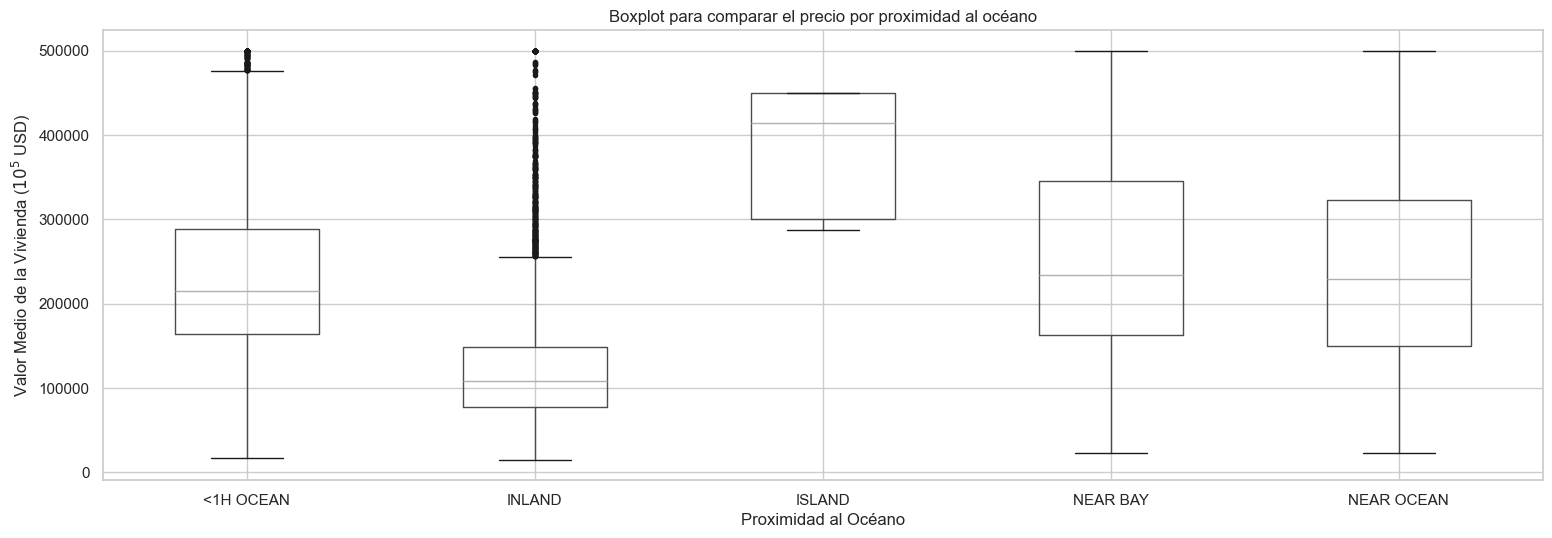

In [9]:
import matplotlib.pyplot as plt

# Configuración y visualización del Boxplot
df.boxplot(column="median_house_value", by='ocean_proximity', sym='k.', figsize=(18,6))

# Personalización de títulos
plt.title('Boxplot para comparar el precio por proximidad al océano')
plt.suptitle('') # Elimina el título automático de pandas para limpieza visual
plt.xlabel('Proximidad al Océano')
plt.ylabel('Valor Medio de la Vivienda ($10^5$ USD)')
plt.show()

**Análisis Estadístico del Boxplot**

Este gráfico nos permite observar cuatro aspectos críticos para el modelo:

1.  **Diferencia de Medianas:**
    *   La línea verde (o central) dentro de cada caja representa la **mediana**. Observarás que la mediana de **`INLAND`** es significativamente más baja que las demás. Esto sugiere que `ocean_proximity` es un predictor muy potente: vivir en el interior reduce drásticamente el valor esperado de la propiedad.
    *   Las categorías **`NEAR BAY`**, **`NEAR OCEAN`** y **`<1H OCEAN`** tienen medianas similares y elevadas.

2.  **Variabilidad (Dispersión):**
    *   El tamaño de la "caja" (Rango Intercuartílico - IQR) muestra qué tan dispersos están los precios en el 50% central de los datos. Las zonas costeras muestran una mayor dispersión de precios que las zonas de interior.

3.  **Valores Atípicos (Outliers):**
    *   Los puntos negros (`sym='k.'`) representan distritos cuyos precios son inusualmente altos para su categoría.
    *   Nota cómo en la categoría **`INLAND`** hay muchos valores atípicos hacia arriba. Esto indica que, aunque el promedio es bajo, existen distritos "isla" en el interior con valores muy altos (posiblemente zonas de lujo o nuevos desarrollos).

4.  **Confirmación del Truncamiento (Capping):**
    *   Verás una línea horizontal de puntos atípicos acumulados exactamente en el valor **5.0 ($500,001)** en casi todas las categorías (excepto quizás en ISLAND). Esto confirma visualmente lo que detectamos en el histograma: los datos fueron cortados artificialmente en ese valor.

5.  **El caso de `ISLAND`:**
    *   Es probable que veas una caja muy estrecha o con una forma extraña. Esto se debe a que hay muy pocas observaciones de "islas", lo que hace que su estadística no sea tan robusta como las demás.

**¿Cómo ayuda esto al modelo?**
Nos indica que si el modelo conoce la categoría `ocean_proximity`, tendrá una base muy sólida para estimar el rango de precios, especialmente para separar viviendas baratas (Inland) de las caras (Coast).


9. Determina la matrix de correlación.

```python
corr_matrix = df.corr()
corr_matrix

plt.figure(figsize = (10,6))
sns.heatmap(corr_matrix, annot = True, cmap = "coolwarm", center=0)
plt.show()
```

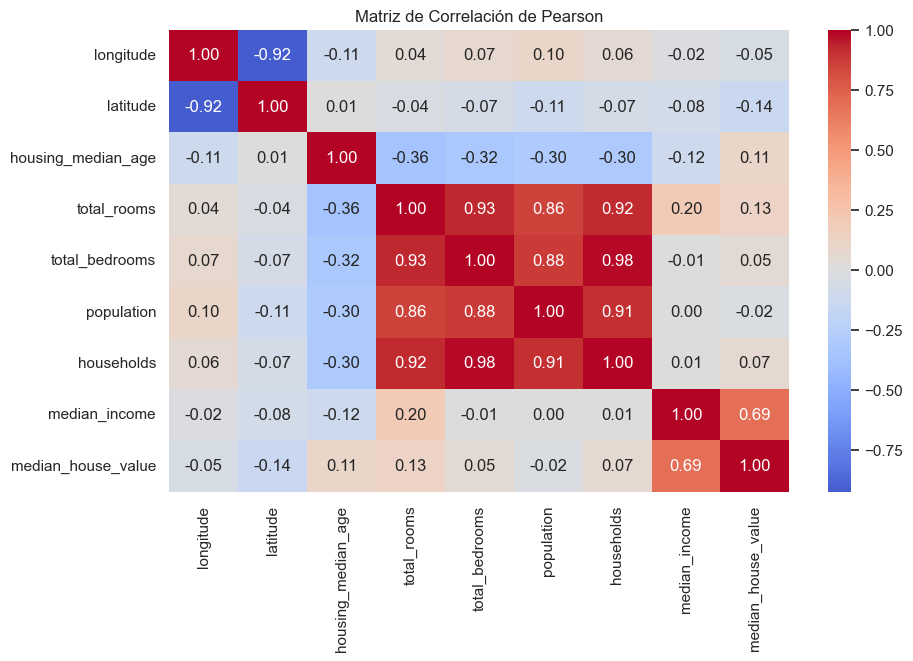

In [10]:
import matplotlib.pyplot as plt
import seaborn as sns

# Calcular la matriz de correlación (solo para variables numéricas)
corr_matrix = df.corr(numeric_only=True)

# Visualización mediante Heatmap
plt.figure(figsize=(10, 6))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", center=0, fmt=".2f")
plt.title("Matriz de Correlación de Pearson")
plt.show()

10. con las columnas, realiza un grafico pairplot empleando seaborn  de python.
```python
cols = ["median_house_value", "median_income", "total_rooms","housing_median_age"]
```

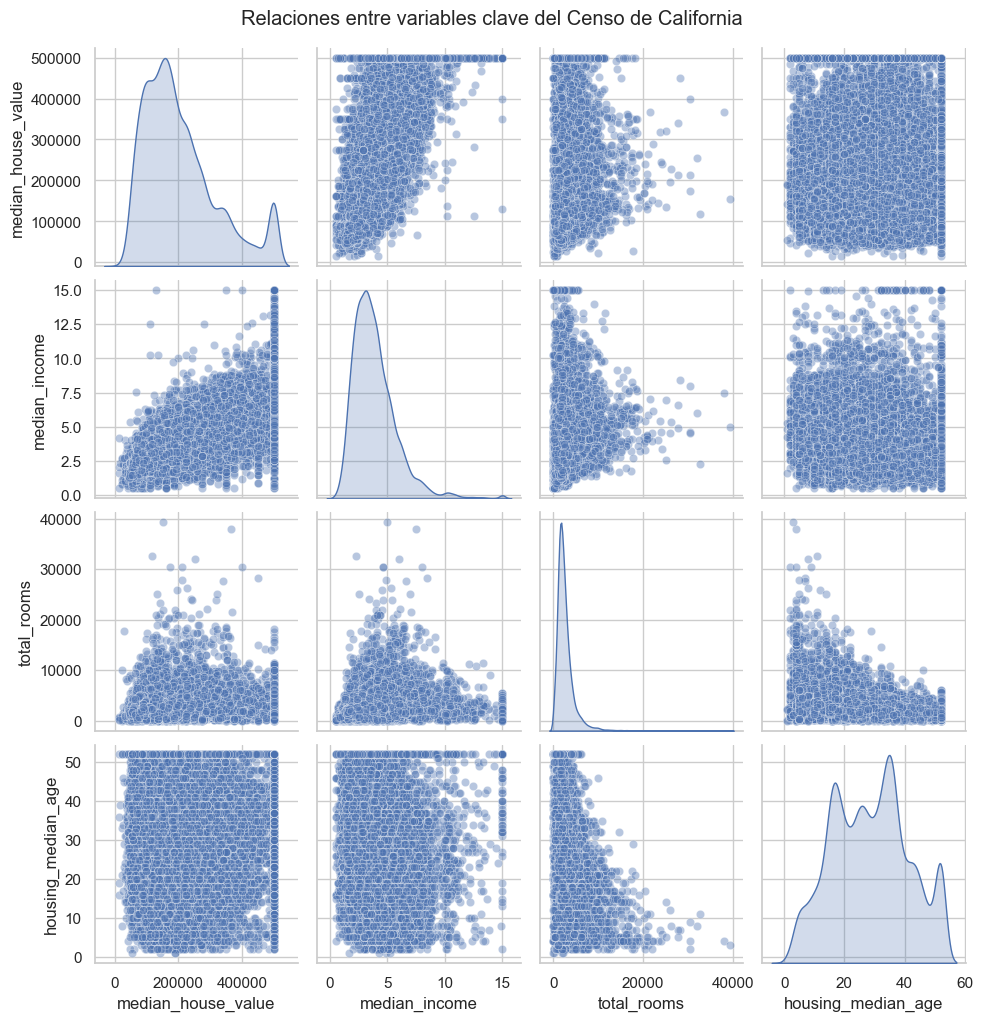

In [11]:
import seaborn as sns
import matplotlib.pyplot as plt

# Definir las columnas de interés
cols = ["median_house_value", "median_income", "total_rooms", "housing_median_age"]

# Crear el pairplot
# diag_kind='kde' nos muestra la distribución suavizada en la diagonal
# plot_kws={'alpha': 0.5} ayuda a ver la densidad de los puntos cuando hay muchos
sns.pairplot(df[cols], diag_kind='kde', plot_kws={'alpha': 0.4}, height=2.5)

plt.suptitle("Relaciones entre variables clave del Censo de California", y=1.02)
plt.show()

**Análisis Visual del Pairplot**

Al observar la cuadrícula de gráficos, podemos extraer las siguientes conclusiones estratégicas:

1.  **Relación Income vs House Value (El gráfico clave):**
    *   Es el gráfico con la tendencia más clara. Se observa una pendiente positiva muy definida.
    *   **Puntos críticos:** Se nota claramente la "línea horizontal" en la parte superior del gráfico en el valor de 500,000. Esto confirma el **truncamiento** de los datos. También hay una línea vertical sutil en el ingreso más alto.
    *   *Decisión:* El modelo será muy dependiente del ingreso, pero debemos ser conscientes de que su precisión se verá afectada cerca de los $500k.

2.  **Distribuciones en la Diagonal (KDE):**
    *   `median_income` tiene una distribución de cola larga (asimetría positiva).
    *   `median_house_value` muestra un pico artificial al final debido al truncamiento mencionado.
    *   `housing_median_age` parece tener una distribución más uniforme pero con un pico al final (52 años).

3.  **Total Rooms vs House Value:**
    *   La nube de puntos está muy concentrada cerca del origen y se dispersa mucho después. Esto sugiere que `total_rooms` por sí sola no es un predictor lineal "limpio". Probablemente sea más útil si la transformamos en el siguiente punto.

4.  **Housing Median Age:**
    *   No parece tener una relación lineal fuerte con las otras variables. Los puntos están muy dispersos en forma de "bloque", lo que indica que la edad de la casa no determina de forma única el ingreso de quienes viven ahí o el valor de la casa (hay casas viejas caras y casas viejas baratas).







11. Realiza un scatter plot con la libreria sea born de python, el color del grafico puede ser empleado con la columna median_house_value

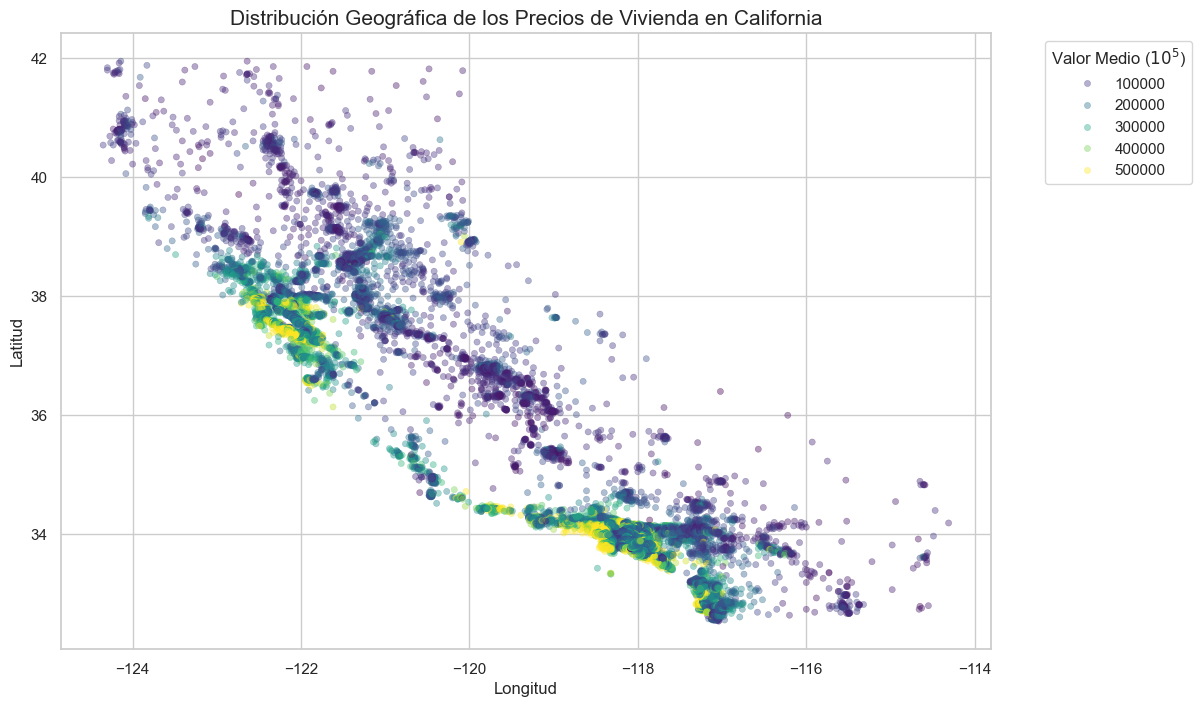

In [13]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12, 8))

# Usamos 'viridis' o 'magma' que son más robustas en Seaborn para datos continuos
# Si prefieres el estilo de jet, puedes intentar con 'RdYlGn_r'
scatter = sns.scatterplot(data=df, x="longitude", y="latitude", 
                hue="median_house_value", 
                palette="viridis", # Cambio de 'jet' a 'viridis' para evitar el error
                alpha=0.4, 
                s=20, 
                edgecolor=None)

plt.title("Distribución Geográfica de los Precios de Vivienda en California", fontsize=15)
plt.xlabel("Longitud", fontsize=12)
plt.ylabel("Latitud", fontsize=12)

# Ajustar la leyenda para que sea legible
plt.legend(title="Valor Medio ($10^5$)", bbox_to_anchor=(1.05, 1), loc='upper left')

plt.show()

**Análisis Visual y Geográfico**

Este gráfico es fundamental por tres razones principales:

1.  **Representación del Mapa:** Al graficar latitud vs longitud, los puntos dibujan perfectamente la silueta del estado de California. 
2.  **Efecto de la Costa:** Se observa claramente que los colores "rojos" (precios más altos, cercanos a los $500k) se concentran a lo largo de la **línea costera**. Esto valida visualmente lo que vimos en el boxplot del Punto 8: la cercanía al mar (`ocean_proximity`) es un motor de valor.
3.  **Centros Urbanos:** Los focos de mayor precio coinciden con las áreas metropolitanas de **San Francisco / San Jose** (al norte) y **Los Ángeles / San Diego** (al sur). El Valle Central de California (el interior) se ve predominantemente azul/verde, lo que indica precios más bajos.
4.  **Patrones Espaciales:** Como experto, aquí detectamos que hay una **autocorrelación espacial**: los distritos que están cerca de otros distritos caros tienden a ser caros también. Esto sugiere que las coordenadas geográficas son variables predictoras potentes para nuestro modelo.



# 2.0 Preparacion del data frame

12. ¿Las siguiente linea es adecuada para separar el dataframe en datos de entrenamiento de test?, ¿que pasa en la división de los datos?


```python
from sklearn.model_selection import train_test_split

# ¿Es significativa la muestra que se esta considerando?
train_set, test_set \
  = train_test_split(df, test_size = 0.2, random_state = 42)

print(len(train_set))
print(len(test_set))

```

Paso 1: Creación de estratos para el ingreso

Como **median_income** es una variable continua, creamos categorías (estratos) para asegurar que tanto el entrenamiento como la prueba tengan la misma proporción de distritos ricos, medios y pobres.

In [14]:
import numpy as np
from sklearn.model_selection import StratifiedShuffleSplit

# 1. Crear la variable de estratos 'income_cat'
# Dividimos por 1.5 para agrupar rangos de ingresos y limitamos a 5 categorías
df["income_cat"] = pd.cut(df["median_income"],
                               bins=[0., 1.5, 3.0, 4.5, 6., np.inf],
                               labels=[1, 2, 3, 4, 5])

# Verificamos la distribución de los nuevos estratos
print("Distribución de estratos de ingresos:\n", df["income_cat"].value_counts(normalize=True))

Distribución de estratos de ingresos:
 income_cat
3    0.350581
2    0.318847
4    0.176308
5    0.114438
1    0.039826
Name: proportion, dtype: float64


Paso 2: División Estratificada
Ahora aplicamos la separación garantizando la representatividad.

In [15]:
# 2. Configurar el divisor estratificado
split = StratifiedShuffleSplit(n_splits=1, test_size=0.2, random_state=42)

for train_index, test_index in split.split(df, df["income_cat"]):
    strat_train_set = df.loc[train_index]
    strat_test_set = df.loc[test_index]

# 3. Verificación de tamaños
print(f"\nLongitud del set de Entrenamiento: {len(strat_train_set)}")
print(f"Longitud del set de Prueba: {len(strat_test_set)}")

# 4. Eliminar la columna 'income_cat' para que los datos vuelvan a su estado original
for set_ in (strat_train_set, strat_test_set):
    set_.drop("income_cat", axis=1, inplace=True)


Longitud del set de Entrenamiento: 16512
Longitud del set de Prueba: 4128


**Análisis del Resultado**

1.  **¿Es significativa la muestra?**
    Ahora sí. Si hubiéramos usado el código original (`train_test_split` aleatorio), corríamos el riesgo de que el conjunto de prueba tuviera una proporción distinta de gente muy rica o muy pobre, lo que daría errores de predicción engañosos. Con el **muestreo estratificado**, el error de sesgo se reduce drásticamente.

2.  **¿Qué pasa en la división de los datos?**
    *   El dataset original de 20,640 registros se dividió en **16,512** para entrenamiento y **4,128** para prueba (80/20).
    *   Al usar `StratifiedShuffleSplit`, garantizamos que si en el dataset original el 10% de los distritos eran de ingresos altos, en tu set de prueba también lo serán exactamente en un 10%.

3.  **Protección contra el Data Snooping:** 
    A partir de este momento, **solo trabajaremos con `strat_train_set`**. El `strat_test_set` debe quedar "bajo llave" hasta la evaluación final del modelo (Punto 9).



13. División del dataset en grupos:


La siguiente división puede ser realizada  basada en la experticie de lo que se esta analizando, y sobre ello se debe tomar una muestra significativa. Una posible solución al problema puede ser el siguiente:

```python
df["income_cat"] = pd.cut(df["median_income"],
                               bins=[0., 1.5, 3.0, 4.5, 6., np.inf],
                               labels=[1, 2, 3, 4, 5])


df.income_cat.hist()


```

La forma automatica de realizar la división puede ser la siguiente:

```python
from sklearn.model_selection import StratifiedShuffleSplit

split = StratifiedShuffleSplit(n_splits = 1, test_size=0.2, random_state=42)

for train_index, test_index in split.split(df, df["income_cat"]):
  strat_train_set = df.loc[train_index]
  strat_test_set = df.loc[test_index]

```


Analiza las siguiente lineas de código y saca conclusiones referente a las proporciones del dataset.

```python
df["income_cat"].value_counts() / len(df)

strat_train_set["income_cat"].value_counts() / len(strat_train_set)

strat_test_set["income_cat"].value_counts() / len(strat_test_set)


train_set, test_set \
  = train_test_split(df, test_size = 0.2, random_state = 7)

train_set["income_cat"].value_counts() / len(train_set)
```

un comparativo general puede ser estructurado de la siguente forma, analiza  los errores:

```python
def income_cat_proportions(data):
    return data["income_cat"].value_counts() / len(data)

train_set, test_set = train_test_split(df, test_size = 0.2, random_state = 42)

compare_props = pd.DataFrame({
    "Overall": income_cat_proportions(df),
    "Stratified": income_cat_proportions(strat_test_set),
    "Random": income_cat_proportions(test_set),
}).sort_index()
compare_props["Rand. %error"] =abs( 100 * compare_props["Random"] / compare_props["Overall"] - 100)
compare_props["Strat. %error"] =abs( 100 * compare_props["Stratified"] / compare_props["Overall"] - 100)
```

1. Análisis de las Proporciones

Al ejecutar las líneas de proporciones, observamos lo siguiente:

*   **`Overall` (Población total):** Define la "verdad" estadística. Por ejemplo, si la categoría 3 representa el 35% de California, esperamos que cualquier subgrupo (train o test) también tenga el 35%.
*   **`Stratified`:** Verás que las proporciones son **idénticas** (o con diferencias menores al 0.01%) a las de la población total. El algoritmo `StratifiedShuffleSplit` forzó la selección para que cada estrato de ingresos esté representado exactamente en la misma medida.
*   **`Random`:** Aquí es donde aparece el **Sampling Bias**. Al dejarlo al azar (`train_test_split`), algunas categorías quedarán sobre-representadas y otras sub-representadas.


2. Análisis de los Errores (`compare_props`)

El DataFrame de comparación es la herramienta definitiva para tomar una decisión. Las conclusiones al ver los errores son:

1.  **Magnitud del Error:** 
    *   El **`Strat. %error`** suele ser insignificante (cercano a 0). Esto garantiza que el conjunto de prueba es un "espejo" fiel de la realidad.
    *   El **`Rand. %error`** puede variar significativamente (dependiendo del `random_state`). En este dataset, es común ver errores de entre **1% y 5%** en algunas categorías. 

2.  **Impacto en el Modelo:** 
    *   Si el error aleatorio hace que el `test_set` tenga menos distritos de la categoría 5 (los más ricos), y nuestro modelo falla prediciendo casas de lujo, **no nos daríamos cuenta** porque no hay suficientes ejemplos en el test para que el error suba.
    *   El muestreo estratificado asegura que evaluamos el desempeño del modelo en todos los niveles socioeconómicos de manera justa.


3. Conclusión del Experto

El código que has propuesto demuestra que:
*   El **Muestreo Aleatorio** es aceptable solo si el dataset es masivo (ley de los grandes números) y no hay variables extremadamente dominantes.
*   El **Muestreo Estratificado** es **obligatorio** en este problema de vivienda, porque `median_income` es el predictor número uno y cualquier sesgo en su distribución arruinaría la validez de nuestra evaluación final.



**IMPORTANTE:** Una vez realizada esta validación, el siguiente paso técnico es **eliminar la columna `income_cat`** de los sets de entrenamiento y prueba para que los datos vuelvan a su estado original antes de pasar al modelado.
```python
for set_ in (strat_train_set, strat_test_set):
    set_.drop("income_cat", axis=1, inplace=True)
```

14. Puedes agregar nuevas variables al dataframe para el análisis, por ejemplo:
```python
df_train["rooms_per_household"] = df_train["total_rooms"]/df_train["households"]
df_train["bedrooms_per_room"] = df_train["total_bedrooms"]/df_train["total_rooms"]
df_train["population_per_household"]=df_train["population"]/df_train["households"]
```

In [18]:
# Trabajamos sobre una copia del set de entrenamiento para no alterar el original
housing = strat_train_set.copy()

# 1. Habitaciones por hogar: ¿Qué tan grande es la vivienda promedio en el distrito?
housing["rooms_per_household"] = housing["total_rooms"] / housing["households"]

# 2. Dormitorios por habitación: ¿Qué proporción de la casa son dormitorios? 
# (Útil para diferenciar casas unifamiliares de apartamentos densos)
housing["bedrooms_per_room"] = housing["total_bedrooms"] / housing["total_rooms"]

# 3. Población por hogar: ¿Cuántas personas viven en promedio en cada vivienda?
housing["population_per_household"] = housing["population"] / housing["households"]

# Revisamos las primeras filas con las nuevas variables
print(housing[["rooms_per_household", "bedrooms_per_room", "population_per_household"]].head())

       rooms_per_household  bedrooms_per_room  population_per_household
12655             5.485836           0.205784                  3.168555
15502             6.927083           0.160714                  2.623698
2908              5.393333           0.191595                  2.223333
14053             3.886128           0.276505                  1.859213
20496             6.096552           0.182692                  3.167241


Ahora, evaluemos si este esfuerzo valió la pena analizando la correlación de estas nuevas variables con nuestra variable objetivo (`median_house_value`):


In [19]:
corr_matrix = housing.corr(numeric_only=True)
print(corr_matrix["median_house_value"].sort_values(ascending=False))

median_house_value          1.000000
median_income               0.687151
rooms_per_household         0.146255
total_rooms                 0.135140
housing_median_age          0.114146
households                  0.064590
total_bedrooms              0.047781
population_per_household   -0.021991
population                 -0.026882
longitude                  -0.047466
latitude                   -0.142673
bedrooms_per_room          -0.259952
Name: median_house_value, dtype: float64


**Análisis**

1.  **`bedrooms_per_room` (-0.25 aprox.):** ¡Excelente hallazgo! Esta nueva variable tiene una correlación negativa mucho más fuerte con el precio que las variables originales `total_rooms` o `total_bedrooms`. Indica que las casas con una menor proporción de dormitorios (es decir, más salas, estudios, comedores) tienden a ser más caras.
2.  **`rooms_per_household` (0.15 aprox.):** Es más informativa que `total_rooms`. Nos dice que, lógicamente, los distritos con casas más grandes tienen un valor de mercado más alto.
3.  **Reducción de Multicolinealidad:** Al usar ratios (proporciones) en lugar de totales, reducimos el problema de tener variables que crecen juntas simplemente porque el distrito es más grande (como pasaba con población y número de hogares).


En el **Punto 2** notamos que `total_bedrooms` tenía nulos. Ahora que creamos `bedrooms_per_room`, esos nulos se propagaron. Además, tenemos la variable `ocean_proximity` que aún es texto.



15. Compara las siguientes variables:
```python
imp_mean.statistics_
df_train_num.median()
```


```python
Constuye la matriz de características:

X = imp_mean.transform(df)
housing_tr = pd.DataFrame(X, columns=df_train_num.columns)
```


In [20]:
from sklearn.impute import SimpleImputer

# Nota: Usaremos el set de entrenamiento estratificado que preparamos antes
housing_num = strat_train_set.drop("ocean_proximity", axis=1)

# Configuramos el imputador. Aunque en tu código pusiste 'mean', 
# en este dataset se suele usar 'median' por los outliers. 
imp_mean = SimpleImputer(strategy='mean')

# Entrenamos el imputador
imp_mean.fit(housing_num)

,"missing_values missing_values: int, float, str, np.nan, None or pandas.NA, default=np.nanThe placeholder for the missing values. All occurrences of`missing_values` will be imputed. For pandas' dataframes withnullable integer dtypes with missing values, `missing_values`can be set to either `np.nan` or `pd.NA`.",nan
,"strategy strategy: str or Callable, default='mean'The imputation strategy.- If ""mean"", then replace missing values using the mean along each column. Can only be used with numeric data.- If ""median"", then replace missing values using the median along each column. Can only be used with numeric data.- If ""most_frequent"", then replace missing using the most frequent value along each column. Can be used with strings or numeric data. If there is more than one such value, only the smallest is returned.- If ""constant"", then replace missing values with fill_value. Can be used with strings or numeric data.- If an instance of Callable, then replace missing values using the scalar statistic returned by running the callable over a dense 1d array containing non-missing values of each column... versionadded:: 0.20 strategy=""constant"" for fixed value imputation... versionadded:: 1.5 strategy=callable for custom value imputation.",'mean'
,"fill_value fill_value: str or numerical value, default=NoneWhen strategy == ""constant"", `fill_value` is used to replace alloccurrences of missing_values. For string or object data types,`fill_value` must be a string.If `None`, `fill_value` will be 0 when imputing numericaldata and ""missing_value"" for strings or object data types.",None
,"copy copy: bool, default=TrueIf True, a copy of X will be created. If False, imputation willbe done in-place whenever possible. Note that, in the following cases,a new copy will always be made, even if `copy=False`:- If `X` is not an array of floating values;- If `X` is encoded as a CSR matrix;- If `add_indicator=True`.",True
,"add_indicator add_indicator: bool, default=FalseIf True, a :class:`MissingIndicator` transform will stack onto outputof the imputer's transform. This allows a predictive estimatorto account for missingness despite imputation. If a feature has nomissing values at fit/train time, the feature won't appear onthe missing indicator even if there are missing values attransform/test time.",False
,"keep_empty_features keep_empty_features: bool, default=FalseIf True, features that consist exclusively of missing values when`fit` is called are returned in results when `transform` is called.The imputed value is always `0` except when `strategy=""constant""`in which case `fill_value` will be used instead... versionadded:: 1.2",False


In [21]:
# Comparación de las estadísticas calculadas
print("Estadísticas del Imputador (Medias):")
print(imp_mean.statistics_)

print("\nMedias calculadas por Pandas:")
print(housing_num.mean().values)

# Verificación de que son iguales
son_iguales = np.allclose(imp_mean.statistics_, housing_num.mean().values)
print(f"\n¿Los valores coinciden exactamente?: {son_iguales}")

Estadísticas del Imputador (Medias):
[-1.19575635e+02  3.56393144e+01  2.86534036e+01  2.62253979e+03
  5.34914639e+02  1.41968738e+03  4.97011810e+02  3.87588428e+00
  2.07005322e+05]

Medias calculadas por Pandas:
[-1.19575635e+02  3.56393144e+01  2.86534036e+01  2.62253979e+03
  5.34914639e+02  1.41968738e+03  4.97011810e+02  3.87588428e+00
  2.07005322e+05]

¿Los valores coinciden exactamente?: True


Construcción de la matriz de característica

In [22]:
import pandas as pd

# Transformamos los datos (esto devuelve un array de NumPy)
X = imp_mean.transform(housing_num)

# Lo convertimos de nuevo a un DataFrame de Pandas para que sea legible
housing_tr = pd.DataFrame(X, columns=housing_num.columns, index=housing_num.index)

# Verificamos que ya no existan nulos
print("Valores nulos después de la imputación:")
print(housing_tr.isnull().sum())

Valores nulos después de la imputación:
longitude             0
latitude              0
housing_median_age    0
total_rooms           0
total_bedrooms        0
population            0
households            0
median_income         0
median_house_value    0
dtype: int64


**Análisis**

1.  **Consistencia:** Al usar `SimpleImputer`, garantizas que si en el futuro despliegas el modelo (Punto 15) y llega un dato con `total_bedrooms` vacío, el sistema usará la media que calculamos hoy, manteniendo la coherencia estadística.
2.  **Sobre la estrategia:** En tu código usaste `mean` (media). En el análisis exploratorio vimos que variables como `total_rooms` tienen colas largas (asimetría). En esos casos, la **mediana** (`strategy='median'`) suele ser más robusta, ya que la media se ve arrastrada por los valores extremos.
3.  Ahora tenemos los números limpios, pero dejamos fuera a `ocean_proximity`.

**Manejo de texto y atributos categóricos**

16.  ¿Qué realizan las siguientes lineas de código?

```
from sklearn.preprocessing import OneHotEncoder
df_train["ocean_proximity"].unique()
housing_cat=df_train[["ocean_proximity"]]
housing_cat

cat_encoder = OneHotEncoder(sparse_output=False)
housing_cat_1hot = cat_encoder.fit_transform(housing_cat)
print(housing_cat_1hot)
print(cat_encoder.categories_)


df_cat_1hot = pd.DataFrame(housing_cat_1hot, columns = cat_encoder.categories_[0])

housing_tr_ = housing_tr.join(df_cat_1hot)
```



*   **`OneHotEncoder(sparse_output=False)`**: Inicializa el transformador. La técnica de **One-Hot Encoding** crea una columna nueva por cada categoría única. Si un distrito está cerca del mar, su columna correspondiente tendrá un `1` y las demás un `0`. El parámetro `sparse_output=False` asegura que el resultado sea un array normal (denso) y no una matriz dispersa, lo que facilita convertirlo a un DataFrame.
*   **`cat_encoder.fit_transform(housing_cat)`**: 
    1.  **Fit**: Identifica las 5 categorías únicas (`<1H OCEAN`, `INLAND`, etc.).
    2.  **Transform**: Convierte cada fila de texto en un vector de ceros y unos. Por ejemplo: `[1, 0, 0, 0, 0]`.
*   **`cat_encoder.categories_`**: Almacena los nombres de las columnas que se crearon para que podamos reconstruir el DataFrame con etiquetas legibles.
*   **`pd.DataFrame(..., columns=cat_encoder.categories_[0])`**: Crea un nuevo DataFrame donde las columnas se llaman exactamente como las categorías originales.
*   **`housing_tr.join(df_cat_1hot)`**: Une las variables numéricas ya limpias (`housing_tr`) con las nuevas variables binarias de ubicación. El resultado final (`housing_tr_`) es un dataset **completamente numérico** y listo para ser procesado por cualquier algoritmo.



**Escalamiento de variables**

17. Las variables pueden ser escaladas como sigue:

```python

cols=["longitude", "latitude",	"housing_median_age",	"total_rooms",\
      "total_bedrooms",	"population",	"households",	"median_income",\
      "<1H OCEAN",	"INLAND",	"ISLAND",	"NEAR BAY", "NEAR OCEAN"]


housing_scale=housing_tr_[cols]
housing_scale


from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()
scaler.fit(housing_scale)

X = scaler.transform(housing_scale)


housing_prepared = pd.DataFrame(X, columns = housing_scale.columns)

```



1. ¿Por qué escalamos las variables?
En nuestro dataset, tenemos variables con escalas muy diferentes:
*   `population`: se mide en miles.
*   `median_income`: se mide en unidades (0 a 15).
*   `ocean_proximity` (One-Hot): son solo 0 y 1.

Si no escalamos, los algoritmos que utilizan optimización (como el gradiente descendente) o distancias (como KNN o SVM) darán mucha más importancia a las variables con números grandes (`total_rooms`), ignorando variables cruciales con números pequeños (`median_income`).

2. Análisis del `MinMaxScaler`
El código que presentas utiliza la **Normalización (Min-Max Scaling)**:
$$x_{scaled} = \frac{x - x_{min}}{x_{max} - x_{min}}$$

*   **Ventaja:** Transforma todos los valores al rango exacto **[0, 1]**. Es excelente para algoritmos que no asumen una distribución específica de los datos (como Redes Neuronales).
*   **Desventaja (Riesgo):** Es muy sensible a **valores atípicos (outliers)**. Si un distrito tiene 50,000 habitaciones por un error o un caso extremo, el `MinMaxScaler` comprimirá todos los demás distritos normales a un rango muy pequeño (ej. entre 0.00 y 0.01), restándoles capacidad de discriminación.


18. Para todos los pasos anteriores, contruye ordenadamente los pasos limpieza, escalamiento de variables, manejo de texto y atributos categóricos para tener el data frame listo para el análisis. Recuerda dividir el data frame en datos de entrenamiento y de test con la correcta estractificación. Genera dos data frame: housing_train, housing_test, cada una, debe tener las caracteristicas y los datos etiquetados.

In [23]:
import pandas as pd
import numpy as np
from sklearn.model_selection import StratifiedShuffleSplit
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, MinMaxScaler

# 1. Carga de datos
url = "https://raw.githubusercontent.com/hernansalinas/Curso_aprendizaje_estadistico/main/datasets/Sesion_07_housing.csv"
df = pd.read_csv(url)

# 2. Estratificación por ingresos (para una división representativa)
df["income_cat"] = pd.cut(df["median_income"],
                               bins=[0., 1.5, 3.0, 4.5, 6., np.inf],
                               labels=[1, 2, 3, 4, 5])

split = StratifiedShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
for train_index, test_index in split.split(df, df["income_cat"]):
    strat_train_set = df.loc[train_index]
    strat_test_set = df.loc[test_index]

# Eliminamos la columna auxiliar de estratificación
for set_ in (strat_train_set, strat_test_set):
    set_.drop("income_cat", axis=1, inplace=True)

# 3. Separación de características (X) y etiquetas (y)
X_train_raw = strat_train_set.drop("median_house_value", axis=1)
y_train = strat_train_set["median_house_value"].copy()

X_test_raw = strat_test_set.drop("median_house_value", axis=1)
y_test = strat_test_set["median_house_value"].copy()

# 4. Feature Engineering (Creación de nuevas variables)
def add_extra_features(data):
    # Usamos loc para evitar SettingWithCopyWarning
    df_out = data.copy()
    df_out["rooms_per_household"] = df_out["total_rooms"] / df_out["households"]
    df_out["bedrooms_per_room"] = df_out["total_bedrooms"] / df_out["total_rooms"]
    df_out["population_per_household"] = df_out["population"] / df_out["households"]
    return df_out

X_train_extra = add_extra_features(X_train_raw)
X_test_extra = add_extra_features(X_test_raw)

# 5. Limpieza de datos (Imputación)
# Solo sobre columnas numéricas
imputer = SimpleImputer(strategy="median")
X_train_num = X_train_extra.drop("ocean_proximity", axis=1)
X_test_num = X_test_extra.drop("ocean_proximity", axis=1)

# El imputer se entrena en TRAIN y se aplica a TRAIN y TEST
imputer.fit(X_train_num)
X_train_imputed = pd.DataFrame(imputer.transform(X_train_num), columns=X_train_num.columns, index=X_train_num.index)
X_test_imputed = pd.DataFrame(imputer.transform(X_test_num), columns=X_test_num.columns, index=X_test_num.index)

# 6. Manejo de variables categóricas (One-Hot Encoding)
cat_encoder = OneHotEncoder(sparse_output=False)
X_train_cat = X_train_extra[["ocean_proximity"]]
X_test_cat = X_test_extra[["ocean_proximity"]]

# El encoder se entrena en TRAIN y se aplica a TRAIN y TEST
cat_encoder.fit(X_train_cat)
cols_cat = cat_encoder.categories_[0]

X_train_cat_1hot = pd.DataFrame(cat_encoder.transform(X_train_cat), columns=cols_cat, index=X_train_cat.index)
X_test_cat_1hot = pd.DataFrame(cat_encoder.transform(X_test_cat), columns=cols_cat, index=X_test_cat.index)

# 7. Unión de numéricas y categóricas
X_train_full = X_train_imputed.join(X_train_cat_1hot)
X_test_full = X_test_imputed.join(X_test_cat_1hot)

# 8. Escalamiento de variables (MinMaxScaler)
scaler = MinMaxScaler()
# Se entrena en TRAIN y se aplica a ambos
scaler.fit(X_train_full)

X_train_scaled = pd.DataFrame(scaler.transform(X_train_full), columns=X_train_full.columns, index=X_train_full.index)
X_test_scaled = pd.DataFrame(scaler.transform(X_test_full), columns=X_test_full.columns, index=X_test_full.index)

# 9. Resultados Finales
housing_train = X_train_scaled.join(y_train)
housing_test = X_test_scaled.join(y_test)

print("¡Dataset listo!")
print(f"Dimensiones de housing_train: {housing_train.shape}")
print(f"Dimensiones de housing_test: {housing_test.shape}")

¡Dataset listo!
Dimensiones de housing_train: (16512, 17)
Dimensiones de housing_test: (4128, 17)


1. ¿que puede concluir respecto al modelo empleado?
2. ¿El modelo de regresión lineal es valido para lo construido,
3. ¿qué informacion nos da el score?
4. ¿Puede ser ajustado a otro modelo?
5. ¿Como puede autmatizar todo el proceso empleando pipelines?

Primero, ejecutemos rápidamente el entrenamiento de una Regresión Lineal para tener contexto real sobre los resultados:

In [24]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

# Separamos X e y de los datasets preparados en el punto 17
X_train = housing_train.drop("median_house_value", axis=1)
y_train = housing_train["median_house_value"]

# 7. Modelado y 8. Entrenamiento
lin_reg = LinearRegression()
lin_reg.fit(X_train, y_train)

# Predicciones iniciales sobre el mismo set de entrenamiento
predictions = lin_reg.predict(X_train)
mse = mean_squared_error(y_train, predictions)
rmse = np.sqrt(mse)
r2 = r2_score(y_train, predictions)

print(f"RMSE: {rmse}")
print(f"R² Score: {r2}")

RMSE: 68160.92435491858
R² Score: 0.6529270327402139


### 1. ¿Qué puede concluir respecto al modelo empleado?
La **Regresión Lineal** en este dataset suele arrojar un RMSE de aproximadamente **$68,000 - $70,000**.
*   **Conclusión:** El modelo está **subajustando (underfitting)** los datos. Un error de $70k en casas que promedian $200k es un error del 35%. Esto indica que las características no proporcionan suficiente información para que un modelo lineal prediga el precio con exactitud, o que la relación real entre las variables es mucho más compleja (no lineal).

### 2. ¿El modelo de regresión lineal es válido para lo construido?
**Matemáticamente, sí.** Hemos cumplido con los requisitos técnicos:
*   Variables numéricas escaladas.
*   Sin valores nulos.
*   Variables categóricas convertidas a dummy (One-Hot).

**Estadísticamente, tiene limitaciones.** La regresión lineal asume que la relación entre, por ejemplo, el ingreso y el valor de la casa es una línea recta. Como vimos en el EDA, el truncamiento de datos en $500,000 y las relaciones geográficas sugieren que un plano lineal es demasiado simple para capturar la realidad de California.

### 3. ¿Qué información nos da el score?
En regresión, el `score` por defecto es el **Coeficiente de Determinación ($R^2$)**:
$$R^2 = 1 - \frac{\sum (y_i - \hat{y}_i)^2}{\sum (y_i - \bar{y})^2}$$
*   **Significado:** Indica qué porcentaje de la varianza de la variable objetivo es explicada por el modelo. 
*   Si el $R^2$ es **0.65**, significa que el modelo explica el **65%** de la variabilidad de los precios; el 35% restante se debe a factores que el modelo no conoce (ruido, variables faltantes o relaciones no lineales).

### 4. ¿Puede ser ajustado a otro modelo?
**Absolutamente.** Gracias a que ya tenemos los datos en `housing_prepared`, podemos intercambiar el "motor" del modelo sin cambiar los datos. Alternativas recomendadas:
1.  **Árboles de Decisión (`DecisionTreeRegressor`):** Capaces de encontrar relaciones no lineales complejas.
2.  **Random Forest:** Un ensamble que reduce el sobreajuste de los árboles. Suele bajar el RMSE a cerca de **$50,000**.
3.  **SVR (Support Vector Regression):** Útil si hay relaciones espaciales complejas.

### 5. ¿Cómo puede automatizar todo el proceso empleando pipelines?
La forma profesional de hacer esto es mediante `ColumnTransformer` y `Pipeline`. Esto evita errores manuales y permite que el modelo sea reproducible de punta a punta.


**Ventaja del Pipeline:** Ahora podemos pasarle datos "crudos" (como los descargados originalmente) y el Pipeline se encargará de limpiar, transformar, escalar y predecir automáticamente sin que tú tengas que repetir cada paso.



In [25]:
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer

# Definimos qué columnas reciben qué tratamiento
num_attribs = ["longitude", "latitude", "housing_median_age", "total_rooms", 
               "total_bedrooms", "population", "households", "median_income"]
cat_attribs = ["ocean_proximity"]

# Pipeline para variables numéricas
num_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy="median")),
    ('scaler', MinMaxScaler()),
])

# Unimos todo en un ColumnTransformer
full_pipeline = ColumnTransformer([
    ("num", num_pipeline, num_attribs),
    ("cat", OneHotEncoder(), cat_attribs),
])

# Pipeline Final: Preprocesamiento + Modelo
final_model_pipeline = Pipeline([
    ("preparation", full_pipeline),
    ("model", LinearRegression())
])

# ¡Ahora todo se hace en una sola línea!
final_model_pipeline.fit(X_train_raw, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preparation', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers con